# FRM Week 1 v4 — Multi-Well Extension

Lanjutan dari `FRM_v3_backup.ipynb`. Notebook v3 udah tervalidasi cocok sama Figure 4 di Amato del Monte (2015), tapi cuma jalan di `qsiwell2`. Notebook ini nambahin dua hal supaya pipeline yang sama bisa dipakai di `qsiwell1`, `qsiwell3`, `qsiwell4`, `qsiwell5` juga, bukan cuma qsiwell2.

**Masalahnya:** kolom di 5 file itu nggak seragam.

| Well | Ada VS? | Ada SWE/SW? |
|---|---|---|
| qsiwell1 | Tidak | Tidak |
| qsiwell2 | Ada | Ada |
| qsiwell3 | Ada | Tidak |
| qsiwell4 | Tidak | Tidak |
| qsiwell5 | Ada (dari DTS) | Tidak |

**Yang ditambahin di v4:**

1. `harmonize_columns()` — normalisasi nama kolom (`SW`/`SWE`, `PHI`/`PHIE`) supaya kode nggak peduli versi penamaan yang dipakai tiap file.
2. Equation 3 (baru) — estimasi Vs dari Vp pakai Greenberg & Castagna (1992), dipakai kalau VS beneran nggak ada (qsiwell1, qsiwell4).
3. Equation 4 (baru) — estimasi Sw, coba Archie kalau ada log resistivity, kalau nggak ada (dan di 4 well ini emang nggak ada satupun), pakai asumsi full-brine (Sw=1) yang **ditulis eksplisit di kolom `SWE_SOURCE`**, bukan ditutup-tutupi.
4. `PHIE_MIN_CUTOFF` — batas porositas minimum sebelum sample dianggap sand yang valid buat Gassmann. Ditemukan pas testing, qsiwell3 punya ratusan sample porositas mendekati nol yang bikin persamaan Gassmann meledak jadi infinity kalau tetap dipaksa disubstitusi.
5. Batch runner yang muter semua 5 well otomatis, plus cross-check Ip hasil hitungan sendiri lawan kolom `IP` yang udah ada di file aslinya (kalau ada), buat mastiin nggak ada kesalahan unit/skala.

Semua equation lama (VRH, Gassmann) **sama persis** kayak di v3, cuma di-reuse di sini, bukan ditulis ulang.

## 2. Import Libraries

In [1]:
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Tuple

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
%matplotlib inline

## 3. Configuration

`WELLS` daftarin semua well yang mau diproses. `ztop`/`zbot` dikosongin (`None`) berarti "pakai seluruh interval yang datanya valid", bukan dipaksa 2100-2400 kayak asumsi v3 yang cuma cocok buat qsiwell2. `reservoir_ztop`/`reservoir_zbot` cuma dipakai buat qsiwell2 karena itu satu-satunya window reservoir yang udah dikonfirmasi (2150-2200 m) dari diskusi sebelumnya.

In [2]:
WORK_DIR = Path(".")
OUTPUT_PATH = WORK_DIR / "outputs"
FIGURE_PATH = OUTPUT_PATH / "figure"
OUTPUT_PATH.mkdir(exist_ok=True)
FIGURE_PATH.mkdir(parents=True, exist_ok=True)

WELLS = [
    {"name": "qsiwell1", "path": "qsiwell1.csv", "ztop": None, "zbot": None},
    {"name": "qsiwell2", "path": "qsiwell2.csv", "ztop": 2100.0, "zbot": 2400.0},
    {"name": "qsiwell3", "path": "qsiwell3.csv", "ztop": None, "zbot": None},
    {"name": "qsiwell4", "path": "qsiwell4.csv", "ztop": None, "zbot": None},
    {"name": "qsiwell5", "path": "qsiwell5.csv", "ztop": None, "zbot": None},
]

# qsiwell2 versi lama pakai SW/PHI, versi terbaru dan well lain pakai
# SWE/PHIE. Dua-duanya diterima, dinormalisasi ke nama kanonik (kanan).
COLUMN_ALIASES: Dict[str, List[str]] = {
    "SWE": ["SWE", "SW"],
    "PHIE": ["PHIE", "PHI"],
}

HARD_REQUIRED_COLUMNS: List[str] = ["DEPTH", "VP", "RHO", "VSH", "PHIE"]

# Kolom resistivity yang dicari sebelum jatuh ke asumsi full-brine.
# Catatan: none of qsiwell1/3/4/5 punya salah satu dari ini sekarang,
# jalur Archie di bawah disiapkan buat kalau suatu saat log resistivity
# ditambahkan, bukan karena aktif kepakai hari ini.
RESISTIVITY_CANDIDATES: List[str] = ["RT", "RESD", "RDEEP", "ILD", "AT90", "RES"]

VSH_CUTOFF = 0.20
SW_CUTOFF = 0.90

# Di bawah porositas ini, inversi dry-frame Gassmann jadi numerically
# unstable (modulus dry-frame mendekati modulus mineral pas phi -> 0,
# jadi penyebut di forward Gassmann meledak). Ditemukan pas testing di
# qsiwell3: ada ~330 sample porositas mendekati nol/negatif (noise
# pembacaan) yang bikin QC ratio jadi infinity kalau tetap dipaksa
# masuk kelas sand. Ini bukan patch numerik, ini memang bukan sand
# yang valid secara fisik buat disubstitusi fluidanya.
PHIE_MIN_CUTOFF = 0.02


@dataclass(frozen=True)
class MineralProperties:
    quartz_density_g_cc: float = 2.65
    quartz_bulk_modulus_gpa: float = 37.0
    quartz_shear_modulus_gpa: float = 44.0
    clay_density_g_cc: float = 2.81
    clay_bulk_modulus_gpa: float = 15.0
    clay_shear_modulus_gpa: float = 5.0


@dataclass(frozen=True)
class FluidProperties:
    brine_density_g_cc: float = 1.09
    brine_bulk_modulus_gpa: float = 2.8
    oil_density_g_cc: float = 0.78
    oil_bulk_modulus_gpa: float = 0.94
    gas_density_g_cc: float = 0.25
    gas_bulk_modulus_gpa: float = 0.06


@dataclass(frozen=True)
class GreenbergCastagnaCoefficients:
    """Vs = a*Vp^2 + b*Vp + c (Vp, Vs dalam km/s). Greenberg & Castagna (1992)."""
    sandstone: Tuple[float, float, float] = (0.0, 0.80416, -0.85588)
    shale: Tuple[float, float, float] = (0.0, 0.76969, -0.86735)


MINERALS = MineralProperties()
FLUIDS = FluidProperties()
GC_COEFFS = GreenbergCastagnaCoefficients()

FACIES_COLORS: List[str] = ["#B3B3B3", "blue", "green", "red", "#996633"]
FACIES_NAMES: Dict[int, str] = {0: "undef", 1: "brine", 2: "oil", 3: "gas", 4: "shale"}
FACIES_CMAP = mcolors.ListedColormap(FACIES_COLORS, "indexed")

IP_XLIM: Tuple[float, float] = (3000.0, 12000.0)
VPVS_YLIM: Tuple[float, float] = (1.4, 3.0)
DPI = 150

## 4. Helper Functions

In [3]:
def ensure_directory(path: Path) -> Path:
    path.mkdir(parents=True, exist_ok=True)
    return path


def validate_columns(df: pd.DataFrame, required_columns: Iterable[str]) -> None:
    missing = [c for c in required_columns if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required column(s): {missing}")


def save_figure(fig: plt.Figure, filename: str, output_dir: Path, dpi: int = DPI) -> Path:
    ensure_directory(output_dir)
    file_path = output_dir / filename
    fig.savefig(file_path, dpi=dpi, bbox_inches="tight")
    plt.close(fig)
    return file_path


def save_dataframe(df: pd.DataFrame, filename: str, output_dir: Path) -> Path:
    ensure_directory(output_dir)
    file_path = output_dir / filename
    df.to_csv(file_path, index=True)
    return file_path


def harmonize_columns(df: pd.DataFrame, aliases: Dict[str, List[str]] = COLUMN_ALIASES) -> pd.DataFrame:
    """Rename whichever alias spelling is present to the canonical name.
    Tidak error kalau nama kanonik maupun aliasnya sama sekali nggak ada,
    itu ditangani di langkah selanjutnya (Sw fallback, estimasi Vs)."""
    df = df.copy()
    rename_map = {}
    for canonical, spellings in aliases.items():
        if canonical in df.columns:
            continue
        for spelling in spellings:
            if spelling in df.columns:
                rename_map[spelling] = canonical
                break
    return df.rename(columns=rename_map)

## 5. Core Physics Equation Functions

### Equation 1: Voigt-Reuss-Hill (sama persis kayak v3)

Dipakai buat ngitung K0 (bulk modulus mineral campuran kuarsa-clay), dan buat ngitung K_fluid (bulk modulus campuran brine-hidrokarbon, komponen Reuss-nya aja).

In [4]:
def voigt_reuss_hill(volume_fractions, bulk_moduli, shear_moduli):
    fractions = np.array(volume_fractions).T
    k = np.resize(np.array(bulk_moduli), np.shape(fractions))
    mu = np.resize(np.array(shear_moduli), np.shape(fractions))
    axis = 0 if fractions.ndim == 1 else 1
    k_voigt = np.sum(fractions * k, axis=axis)
    k_reuss = 1.0 / np.sum(fractions / k, axis=axis)
    mu_voigt = np.sum(fractions * mu, axis=axis)
    with np.errstate(divide="ignore", invalid="ignore"):
        mu_reuss = 1.0 / np.sum(fractions / mu, axis=axis)
    k_vrh = (k_voigt + k_reuss) / 2.0
    mu_vrh = (mu_voigt + mu_reuss) / 2.0
    return k_voigt, k_reuss, mu_voigt, mu_reuss, k_vrh, mu_vrh

### Equation 2: Gassmann fluid substitution (sama persis kayak v3)

In [5]:
def gassmann_fluid_substitution(vp1, vs1, rho1, rho_fluid1, k_fluid1, rho_fluid2, k_fluid2, k_mineral, porosity):
    vp1_km_s = vp1 / 1000.0
    vs1_km_s = vs1 / 1000.0
    rho2 = rho1 - porosity * rho_fluid1 + porosity * rho_fluid2
    mu1 = rho1 * vs1_km_s ** 2.0
    k1 = rho1 * vp1_km_s ** 2.0 - (4.0 / 3.0) * mu1
    k_dry = (k1 * ((porosity * k_mineral) / k_fluid1 + 1.0 - porosity) - k_mineral) / (
        (porosity * k_mineral) / k_fluid1 + (k1 / k_mineral) - 1.0 - porosity
    )
    k2 = k_dry + (1.0 - (k_dry / k_mineral)) ** 2 / (
        (porosity / k_fluid2) + ((1.0 - porosity) / k_mineral) - (k_dry / k_mineral ** 2)
    )
    mu2 = mu1
    vp2 = np.sqrt((k2 + (4.0 / 3.0) * mu2) / rho2) * 1000.0
    vs2 = np.sqrt(mu2 / rho2) * 1000.0
    return vp2, vs2, rho2, k2

### Equation 3 (BARU): Greenberg-Castagna (1992) — estimasi Vs dari Vp

**Purpose.** Ngasih nilai Vs buat well yang emang nggak pernah punya shear log (qsiwell1, qsiwell4), supaya suku mu1 = rho1 x vs1² di Gassmann ada isinya. Ini transform empiris tergantung litologi, BUKAN hukum fisika, jadi cuma dipakai kalau kolom VS beneran nggak ada, dan tiap sample yang diestimasi ditandai lewat `VS_SOURCE` biar nggak ketuker sama data terukur.

**Input.** `vp_m_s` (Vp terukur, m/s), `vsh` (volume shale, fraksi 0-1).

**Equation** (Greenberg & Castagna, 1992, koefisien dari tabel cookbook sandstone/shale di Mavko, Mukerji, & Dvorkin, 2009):

Vs = a·Vp² + b·Vp + c, dengan Vp dan Vs dalam km/s

- Sandstone (Vsh ≤ cutoff): a=0.0, b=0.80416, c=-0.85588
- Shale (Vsh > cutoff): a=0.0, b=0.76969, c=-0.86735

**Output.** `vs_m_s`, estimasi Vs dalam m/s.

**Validasi akurasi** (dites ke 3 well yang beneran punya Vs terukur, qsiwell2, qsiwell3, qsiwell5, hasil lengkapnya ada di Section 10):

| Well | RMSE | MAPE | korelasi (r) |
|---|---|---|---|
| qsiwell2 | 183.9 m/s | 9.34% | 0.939 |
| qsiwell3 | 47.2 m/s | 2.19% | 0.999 |
| qsiwell5 | 113.7 m/s | 8.72% | 0.954 |

Akurasinya bervariasi antar well (paling bagus di qsiwell3, paling kasar di qsiwell2), ini emang karakter wajar dari model empiris dua-parameter kayak gini, konsisten sama benchmark yang dilaporin studi terbaru (Makarian et al., 2023).

In [6]:
def estimate_vs_greenberg_castagna(
    vp_m_s: np.ndarray, vsh: np.ndarray, vsh_cutoff: float = VSH_CUTOFF, coeffs: GreenbergCastagnaCoefficients = GC_COEFFS
) -> np.ndarray:
    """Estimasi Vs (m/s) dari Vp (m/s) dan Vsh pakai Greenberg-Castagna (1992)."""
    vp_km_s = vp_m_s / 1000.0
    is_shale = vsh > vsh_cutoff
    a_s, b_s, c_s = coeffs.sandstone
    a_sh, b_sh, c_sh = coeffs.shale
    vs_km_s = np.where(
        is_shale,
        a_sh * vp_km_s ** 2 + b_sh * vp_km_s + c_sh,
        a_s * vp_km_s ** 2 + b_s * vp_km_s + c_s,
    )
    return vs_km_s * 1000.0

### Equation 4 (BARU): Sw — Archie kalau bisa, asumsi full-brine eksplisit kalau nggak bisa

**Purpose.** Ngisi kolom SWE buat well yang nggak punya (qsiwell1, qsiwell3, qsiwell4, qsiwell5, keempatnya nggak punya SWE DAN nggak punya log resistivity apapun, sudah dicek ke `RESISTIVITY_CANDIDATES`). Tanpa Rt, persamaan Archie (1942) nggak bisa jalan, titik, nggak ada equation yang bisa bikin Sw dari Vp/RHO/VSH doang. Jadi fallback yang dipakai di sini adalah Sw=1 (full brine) di semua sample, yang memang jadi asumsi default standar buat well tanpa indikasi hidrokarbon dari log (Avseth, Mukerji, & Mavko, 2005), BUKAN tebakan yang didiemin.

**Equation.** Kalau Rt ada (Archie 1942, clean sand): 
Sw = ((a·Rw)/(Rt·phi^m))^(1/n). 
Kalau Rt nggak ada: Sw = 1.0 di semua sample (asumsi, bukan hasil pengukuran atau model).

**Output.** `(sw_array, source_label)`, label-nya salah satu dari `"measured"`, `"archie_estimated_from_<kolom>"`, atau `"assumed_full_brine_no_resistivity_log"`.

**KONSEKUENSI PENTING** (baca ini sebelum percaya LFC=2 "oil sand" muncul di well manapun selain qsiwell2): di bawah asumsi full-brine, klasifikasi LFC di keempat well itu cuma bisa jadi kelas 1 (brine) atau kelas 4 (shale), kelas 2 (oil) nggak akan pernah muncul secara in-situ. Gassmann tetap dijalanin buat skenario OIL dan GAS (itu emang skenario sintetik by design, nggak bergantung ke Sw in-situ), yang kepengaruh cuma label LFC in-situ-nya doang.

In [7]:
def estimate_sw(
    df: pd.DataFrame, resistivity_candidates: List[str] = RESISTIVITY_CANDIDATES, a: float = 1.0, m: float = 2.0, n: float = 2.0, rw: float = 0.05
) -> Tuple[np.ndarray, str]:
    """Return (sw_array, source_label). Coba Archie kalau ada kolom
    resistivity, kalau nggak ada, asumsi full-brine dan bilang terus terang."""
    if "SWE" in df.columns:
        return df["SWE"].values, "measured"

    rt_col = next((c for c in resistivity_candidates if c in df.columns), None)
    if rt_col is not None:
        sw = ((a * rw) / (df[rt_col].values * (df["PHIE"].values ** m))) ** (1.0 / n)
        sw = np.clip(sw, 0.0, 1.0)
        return sw, f"archie_estimated_from_{rt_col}"

    sw = np.ones(len(df))
    return sw, "assumed_full_brine_no_resistivity_log"

## 6. Load & Harmonize satu well

Gabungan dari harmonisasi kolom + estimasi Vs/Sw kalau perlu + auto depth-window (drop NaN, bukan hardcode 2100-2400) + clip PHIE ke [0,1].

In [8]:
def load_and_prepare_well(
    path: Path, ztop: Optional[float] = None, zbot: Optional[float] = None
) -> Tuple[pd.DataFrame, Dict[str, object]]:
    if not Path(path).exists():
        raise FileNotFoundError(f"Well file not found: {path}")

    df = pd.read_csv(path)
    df = harmonize_columns(df)
    validate_columns(df, HARD_REQUIRED_COLUMNS)

    # Beberapa sample di data mentah punya PHIE dikit di bawah 0 (noise
    # pembulatan), clip daripada dibuang biar nggak kehilangan row cuma
    # gara-gara artifact -0.007.
    n_clipped = int(((df["PHIE"] < 0) | (df["PHIE"] > 1)).sum())
    df["PHIE"] = df["PHIE"].clip(0.0, 1.0)

    df = df.set_index("DEPTH")
    if ztop is not None:
        df = df[df.index >= ztop]
    if zbot is not None:
        df = df[df.index <= zbot]

    n_before = len(df)
    df = df.dropna(subset=[c for c in HARD_REQUIRED_COLUMNS if c != "DEPTH"])
    n_after = len(df)

    if df.empty:
        raise ValueError(f"No valid rows left for {path} after dropping NaNs.")

    if "VS" in df.columns and df["VS"].notna().all():
        vs_source = "measured"
    else:
        df["VS"] = estimate_vs_greenberg_castagna(df["VP"].values, df["VSH"].values)
        vs_source = "estimated_greenberg_castagna_1992"

    sw_values, sw_source = estimate_sw(df)
    df["SWE"] = sw_values

    metadata = {
        "n_rows_raw": n_before,
        "n_rows_after_dropna": n_after,
        "n_phie_clipped": n_clipped,
        "vs_source": vs_source,
        "sw_source": sw_source,
    }
    return df, metadata

## 7. Processing Pipeline (Step 1-9, logic sama kayak v3, di-reuse)

In [9]:
def classify_lithofluid_class(df, vsh_cutoff=VSH_CUTOFF, sw_cutoff=SW_CUTOFF, phie_min_cutoff=PHIE_MIN_CUTOFF):
    df = df.copy()
    is_sand = (df["VSH"] <= vsh_cutoff) & (df["PHIE"] >= phie_min_cutoff)
    is_brine_sand = is_sand & (df["SWE"] >= sw_cutoff)
    is_oil_sand = is_sand & (df["SWE"] < sw_cutoff)
    is_shale = df["VSH"] > vsh_cutoff
    lfc = np.zeros(len(df), dtype=int)
    lfc[is_brine_sand.values] = 1
    lfc[is_oil_sand.values] = 2
    lfc[is_shale.values] = 4
    # sample yang bukan sand (gagal cutoff porositas) dan bukan shale
    # sengaja dibiarin LFC=0 (undefined), nggak dipaksa masuk kelas manapun
    df["LFC"] = lfc
    return df


def calculate_mineral_bulk_modulus(df, minerals=MINERALS):
    df = df.copy()
    shale = df["VSH"].values
    sand = 1.0 - shale - df["PHIE"].values
    sand = np.clip(sand, 1e-6, None)
    total = shale + sand
    shale_norm = shale / total
    sand_norm = sand / total
    _, _, _, _, k0, _ = voigt_reuss_hill(
        [shale_norm, sand_norm],
        [minerals.clay_bulk_modulus_gpa, minerals.quartz_bulk_modulus_gpa],
        [minerals.clay_shear_modulus_gpa, minerals.quartz_shear_modulus_gpa],
    )
    df["K0"] = k0
    return df


def calculate_insitu_fluid_density(df, fluids=FLUIDS):
    df = df.copy()
    water = df["SWE"].values
    hydrocarbon = 1.0 - water
    df["RHO_FLUID"] = water * fluids.brine_density_g_cc + hydrocarbon * fluids.oil_density_g_cc
    return df


def calculate_insitu_fluid_bulk_modulus(df, fluids=FLUIDS):
    df = df.copy()
    water = df["SWE"].values
    hydrocarbon = 1.0 - water
    _, k_reuss, _, _, _, _ = voigt_reuss_hill(
        [water, hydrocarbon], [fluids.brine_bulk_modulus_gpa, fluids.oil_bulk_modulus_gpa], [0.0, 0.0]
    )
    df["K_FLUID"] = k_reuss
    return df


SCENARIO_SUFFIXES = {"BRINE": "FRMB", "OIL": "FRMO", "GAS": "FRMG"}
SCENARIO_LFC_CODE = {"BRINE": 1, "OIL": 2, "GAS": 3}


def apply_gassmann_scenario(df, scenario, fluids=FLUIDS):
    df = df.copy()
    suffix = SCENARIO_SUFFIXES[scenario]
    is_sand = df["LFC"].isin([1, 2]).values
    target_density = {"BRINE": fluids.brine_density_g_cc, "OIL": fluids.oil_density_g_cc, "GAS": fluids.gas_density_g_cc}[scenario]
    target_bulk_modulus = {"BRINE": fluids.brine_bulk_modulus_gpa, "OIL": fluids.oil_bulk_modulus_gpa, "GAS": fluids.gas_bulk_modulus_gpa}[scenario]
    vp2, vs2, rho2, _ = gassmann_fluid_substitution(
        df["VP"].values, df["VS"].values, df["RHO"].values, df["RHO_FLUID"].values, df["K_FLUID"].values,
        np.full(len(df), target_density), np.full(len(df), target_bulk_modulus), df["K0"].values, df["PHIE"].values,
    )
    vp_col, vs_col, rho_col = f"VP_{suffix}", f"VS_{suffix}", f"RHO_{suffix}"
    df[vp_col] = df["VP"]; df[vs_col] = df["VS"]; df[rho_col] = df["RHO"]
    df.loc[is_sand, vp_col] = vp2[is_sand]
    df.loc[is_sand, vs_col] = vs2[is_sand]
    df.loc[is_sand, rho_col] = rho2[is_sand]
    lfc_scenario = np.zeros(len(df), dtype=int)
    lfc_scenario[is_sand] = SCENARIO_LFC_CODE[scenario]
    lfc_scenario[df["LFC"].values == 4] = 4
    df[f"LFC_{scenario[0]}"] = lfc_scenario
    return df


def calculate_acoustic_impedance(df, suffixes=("", "_FRMB", "_FRMO", "_FRMG")):
    df = df.copy()
    for sfx in suffixes:
        df[f"IP{sfx}"] = df[f"VP{sfx}"] * df[f"RHO{sfx}"]
    return df


def calculate_vpvs_ratio(df, suffixes=("", "_FRMB", "_FRMO", "_FRMG")):
    df = df.copy()
    for sfx in suffixes:
        df[f"VPVS{sfx}"] = df[f"VP{sfx}"] / df[f"VS{sfx}"]
    return df


def calculate_dry_frame_qc_ratio(df):
    df = df.copy()
    df["QC_RATIO"] = df["VP_FRMB"] / df["VP"]
    return df

## 8. Validation

Tiga lapis QC: (1) cek missing value, (2) fluid-substitution QC dari v3 (sample brine murni yang "disubstitusi ke brine" harus balik ke nilai asal, ratio ~1), (3) BARU, cross-check Ip hasil hitungan sendiri lawan kolom `IP` yang udah ada di file mentah (kalau file itu punya), buat nangkep kesalahan unit/skala sedini mungkin.

In [10]:
def check_missing_values(df, columns):
    return {c: int(df[c].isna().sum()) for c in columns if c in df.columns}


def cross_check_impedance(df: pd.DataFrame, original_ip_col: str = "IP_ORIGINAL") -> Optional[Dict[str, float]]:
    if original_ip_col not in df.columns:
        return None
    diff_pct = ((df["IP"] - df[original_ip_col]).abs() / df[original_ip_col].abs()) * 100
    return {"mean_abs_diff_pct": float(diff_pct.mean()), "max_abs_diff_pct": float(diff_pct.max())}


def run_fluid_substitution_qc(df, tolerance=0.01, pure_brine_sw=0.98):
    brine_sand = df[(df["LFC"] == 1) & (df["SWE"] >= pure_brine_sw)]
    if brine_sand.empty:
        return {"max_deviation": 0.0, "n_failed": 0, "passed": True}
    deviation = (brine_sand["QC_RATIO"] - 1.0).abs()
    n_failed = int((deviation > tolerance).sum())
    return {"max_deviation": float(deviation.max()), "n_failed": n_failed, "passed": n_failed == 0}

## 9. Visualization (3 plot per well: log track, crossplot in-situ, crossplot 4-skenario FRM)

In [11]:
def plot_well_log_track(df, output_dir, well_name):
    cluster = np.repeat(np.expand_dims(df["LFC"].values, 1), 100, 1)
    fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(8, 6))
    axes[0].plot(df["VSH"], df.index, "-g", label="Vsh")
    axes[0].plot(df["SWE"], df.index, "-b", label="Sw")
    axes[0].plot(df["PHIE"], df.index, "-k", label="phi")
    axes[0].legend(loc="lower right", fontsize=8)
    axes[1].plot(df["IP"], df.index, "-", color="0.5")
    axes[2].plot(df["VPVS"], df.index, "-", color="0.5")
    image = axes[3].imshow(cluster, interpolation="none", aspect="auto", cmap=FACIES_CMAP, vmin=0, vmax=4, origin="lower")
    fig.colorbar(image, ax=axes[3])
    for ax, title in zip(axes, ["Vsh / Sw / phi", "Ip", "Vp/Vs", "LFC"]):
        ax.invert_yaxis(); ax.set_title(title, fontsize=9); ax.grid()
    for ax in axes[1:]:
        ax.set_yticklabels([]); ax.tick_params(axis="y", left=False)
    fig.suptitle(f"{well_name} \u2014 well log track")
    return save_figure(fig, f"{well_name}_well_log_track.png", output_dir)


def plot_original_crossplot(df, output_dir, well_name):
    fig, ax = plt.subplots(figsize=(7, 5.5))
    scatter = ax.scatter(df["IP"], df["VPVS"], s=15, c=df["LFC"], marker="o", edgecolors="none", alpha=0.6, cmap=FACIES_CMAP, vmin=0, vmax=4)
    ax.set_xlim(*IP_XLIM); ax.set_ylim(*VPVS_YLIM)
    ax.set_xlabel("Ip"); ax.set_ylabel("Vp/Vs"); ax.grid(True)
    ax.set_title(f"{well_name} \u2014 in-situ crossplot")
    cbar = fig.colorbar(scatter, ax=ax)
    cbar.set_label((10 * " ").join(["undef", "brine", "oil", "gas", "shale"]))
    cbar.set_ticks([])
    return save_figure(fig, f"{well_name}_original_crossplot.png", output_dir)


def plot_frm_crossplot(df, output_dir, well_name):
    fig, axes = plt.subplots(nrows=1, ncols=4, sharey=True, sharex=True, figsize=(16, 4))
    panels = [("IP", "VPVS", "LFC", "in-situ"), ("IP_FRMB", "VPVS_FRMB", "LFC_B", "brine"),
              ("IP_FRMO", "VPVS_FRMO", "LFC_O", "oil"), ("IP_FRMG", "VPVS_FRMG", "LFC_G", "gas")]
    for ax, (ip_col, vpvs_col, lfc_col, title) in zip(axes, panels):
        ax.scatter(df[ip_col], df[vpvs_col], 15, df[lfc_col], marker="o", edgecolors="none", alpha=0.5, cmap=FACIES_CMAP, vmin=0, vmax=4)
        ax.set_title(title); ax.grid()
    axes[0].set_xlim(*IP_XLIM); axes[0].set_ylim(*VPVS_YLIM)
    axes[0].set_xlabel("Ip"); axes[0].set_ylabel("Vp/Vs")
    fig.suptitle(f"{well_name} \u2014 FRM scenarios (in-situ / brine / oil / gas)")
    return save_figure(fig, f"{well_name}_frm_crossplot.png", output_dir)

## 10. Validasi akurasi Vs (Greenberg-Castagna) sebelum dipercaya\n\nDites ke well yang BENERAN punya Vs terukur (qsiwell2, qsiwell3, qsiwell5). Formula yang sama dijalanin seolah-olah Vs-nya nggak ada, hasilnya dibandingin ke Vs yang asli. Ini bukti akurasi, bukan cuma klaim.

In [12]:
vs_validation_rows = []
for well_name in ["qsiwell2", "qsiwell3", "qsiwell5"]:
    raw = pd.read_csv(f"{well_name}.csv")
    raw = harmonize_columns(raw).dropna(subset=["VP", "VS", "VSH"])
    vs_est = estimate_vs_greenberg_castagna(raw["VP"].values, raw["VSH"].values)
    err = vs_est - raw["VS"].values
    rmse = float(np.sqrt(np.mean(err ** 2)))
    mape = float(np.mean(np.abs(err) / raw["VS"].values) * 100)
    corr = float(np.corrcoef(vs_est, raw["VS"].values)[0, 1])
    vs_validation_rows.append({"well": well_name, "n": len(raw), "rmse_m_s": round(rmse, 1), "mape_pct": round(mape, 2), "r": round(corr, 3)})

vs_validation_df = pd.DataFrame(vs_validation_rows).set_index("well")
print(vs_validation_df)

              n  rmse_m_s  mape_pct      r
well                                      
qsiwell2   4113     183.9      9.34  0.939
qsiwell3  31594      47.2      2.19  0.999
qsiwell5   1313     113.7      8.72  0.954


## 11. Run all 5 wells

In [13]:
def run_one_well(well_cfg: dict) -> Tuple[pd.DataFrame, dict]:
    name = well_cfg["name"]
    df, meta = load_and_prepare_well(WORK_DIR / well_cfg["path"], well_cfg["ztop"], well_cfg["zbot"])

    if "IP" in df.columns:
        df = df.rename(columns={"IP": "IP_ORIGINAL"})

    df = classify_lithofluid_class(df)
    df = calculate_mineral_bulk_modulus(df)
    df = calculate_insitu_fluid_density(df)
    df = calculate_insitu_fluid_bulk_modulus(df)
    df = calculate_acoustic_impedance(df, suffixes=("",))
    df = calculate_vpvs_ratio(df, suffixes=("",))

    for scenario in ("BRINE", "OIL", "GAS"):
        df = apply_gassmann_scenario(df, scenario)
    df = calculate_acoustic_impedance(df, suffixes=("_FRMB", "_FRMO", "_FRMG"))
    df = calculate_vpvs_ratio(df, suffixes=("_FRMB", "_FRMO", "_FRMG"))
    df = calculate_dry_frame_qc_ratio(df)

    missing_report = check_missing_values(df, HARD_REQUIRED_COLUMNS + ["VS", "SWE"])
    qc_report = run_fluid_substitution_qc(df)
    ip_cross_check = cross_check_impedance(df)
    facies_counts = df["LFC"].value_counts().to_dict()

    well_report = {
        "well": name, **meta, "n_rows_final": len(df),
        "facies_counts": {FACIES_NAMES.get(k, k): v for k, v in facies_counts.items()},
        "missing_values": missing_report, "fluid_substitution_qc": qc_report,
        "ip_cross_check_vs_original": ip_cross_check,
    }

    ensure_directory(FIGURE_PATH)
    plot_well_log_track(df, FIGURE_PATH, name)
    plot_original_crossplot(df, FIGURE_PATH, name)
    plot_frm_crossplot(df, FIGURE_PATH, name)
    save_dataframe(df, f"{name}_frm_results.csv", OUTPUT_PATH)
    return df, well_report


all_results = {}
all_reports = []
for well_cfg in WELLS:
    print(f"Processing {well_cfg['name']} ...")
    df_result, report = run_one_well(well_cfg)
    all_results[well_cfg["name"]] = df_result
    all_reports.append(report)
    print(f"  rows: {report['n_rows_final']}, VS source: {report['vs_source']}, SWE source: {report['sw_source']}")
    print(f"  facies counts: {report['facies_counts']}")
    print(f"  fluid substitution QC: {report['fluid_substitution_qc']}")
    if report["ip_cross_check_vs_original"]:
        print(f"  IP cross-check vs original IP column: {report['ip_cross_check_vs_original']}")
    print()

combined = pd.concat(
    [df.reset_index().assign(WELL=name) for name, df in all_results.items()],
    ignore_index=True, sort=False,
)
save_dataframe(combined.set_index(["WELL", "DEPTH"]), "combined_multiwell_frm_results.csv", OUTPUT_PATH)
print("=" * 60)
print(f"ALL WELLS PROCESSED OK. Combined rows: {len(combined)}")
print("=" * 60)

Processing qsiwell1 ...


  rows: 11220, VS source: estimated_greenberg_castagna_1992, SWE source: assumed_full_brine_no_resistivity_log
  facies counts: {'shale': 9488, 'brine': 1732}
  fluid substitution QC: {'max_deviation': 2.220446049250313e-16, 'n_failed': 0, 'passed': True}
  IP cross-check vs original IP column: {'mean_abs_diff_pct': 6.4353642758520665e-15, 'max_abs_diff_pct': 3.1463383889627134e-14}

Processing qsiwell2 ...


  rows: 1968, VS source: measured, SWE source: measured
  facies counts: {'shale': 1128, 'brine': 706, 'oil': 134}
  fluid substitution QC: {'max_deviation': 0.003150513624426754, 'n_failed': 0, 'passed': True}
  IP cross-check vs original IP column: {'mean_abs_diff_pct': 1.3931680725025078e-14, 'max_abs_diff_pct': 1.1377919507710947e-13}

Processing qsiwell3 ...


  rows: 28955, VS source: measured, SWE source: assumed_full_brine_no_resistivity_log
  facies counts: {'brine': 19091, 'shale': 8701, 'undef': 1163}
  fluid substitution QC: {'max_deviation': 6.006306563222097e-14, 'n_failed': 0, 'passed': True}
  IP cross-check vs original IP column: {'mean_abs_diff_pct': 4.819257295481642e-15, 'max_abs_diff_pct': 5.840284532817143e-14}

Processing qsiwell4 ...


  rows: 1297, VS source: estimated_greenberg_castagna_1992, SWE source: assumed_full_brine_no_resistivity_log
  facies counts: {'shale': 1014, 'brine': 283}
  fluid substitution QC: {'max_deviation': 4.3298697960381105e-15, 'n_failed': 0, 'passed': True}
  IP cross-check vs original IP column: {'mean_abs_diff_pct': 6.225157221066851e-15, 'max_abs_diff_pct': 3.3498218372528614e-14}

Processing qsiwell5 ...


  rows: 1313, VS source: measured, SWE source: assumed_full_brine_no_resistivity_log
  facies counts: {'shale': 944, 'brine': 369}
  fluid substitution QC: {'max_deviation': 8.881784197001252e-16, 'n_failed': 0, 'passed': True}
  IP cross-check vs original IP column: {'mean_abs_diff_pct': 1.0236828094582147e-10, 'max_abs_diff_pct': 2.9928376915917325e-10}



ALL WELLS PROCESSED OK. Combined rows: 44753


### Cek visual, qsiwell2 (well yang udah tervalidasi sebelumnya, buat mastiin v4 nggak ngerusak hasil v3)

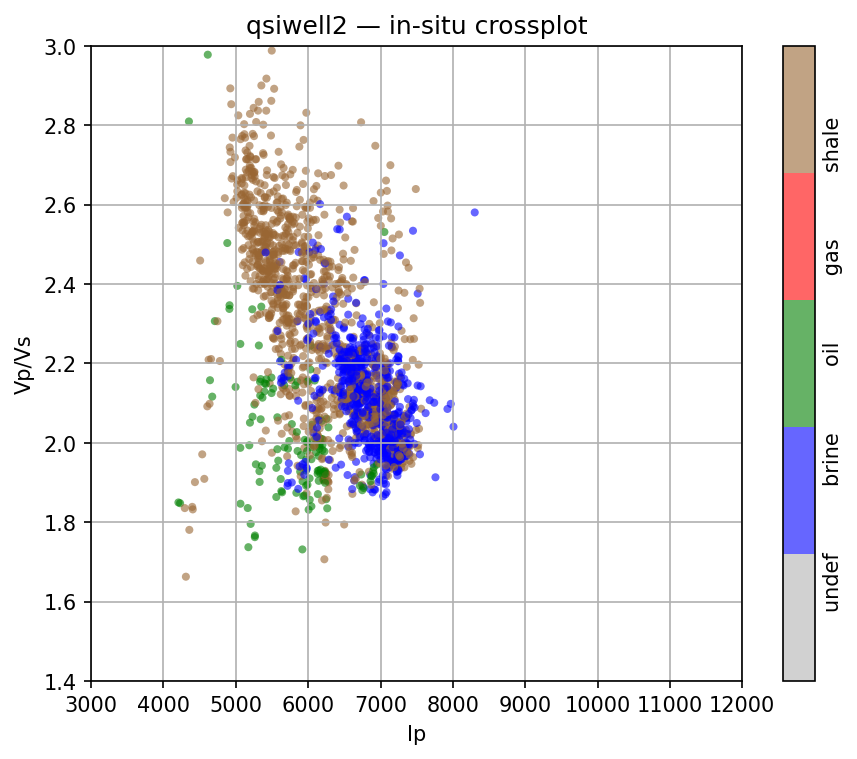

In [14]:
from IPython.display import Image, display
display(Image(filename=str(FIGURE_PATH / "qsiwell2_original_crossplot.png")))

### Cek visual, qsiwell3 (well baru, paling banyak datanya)

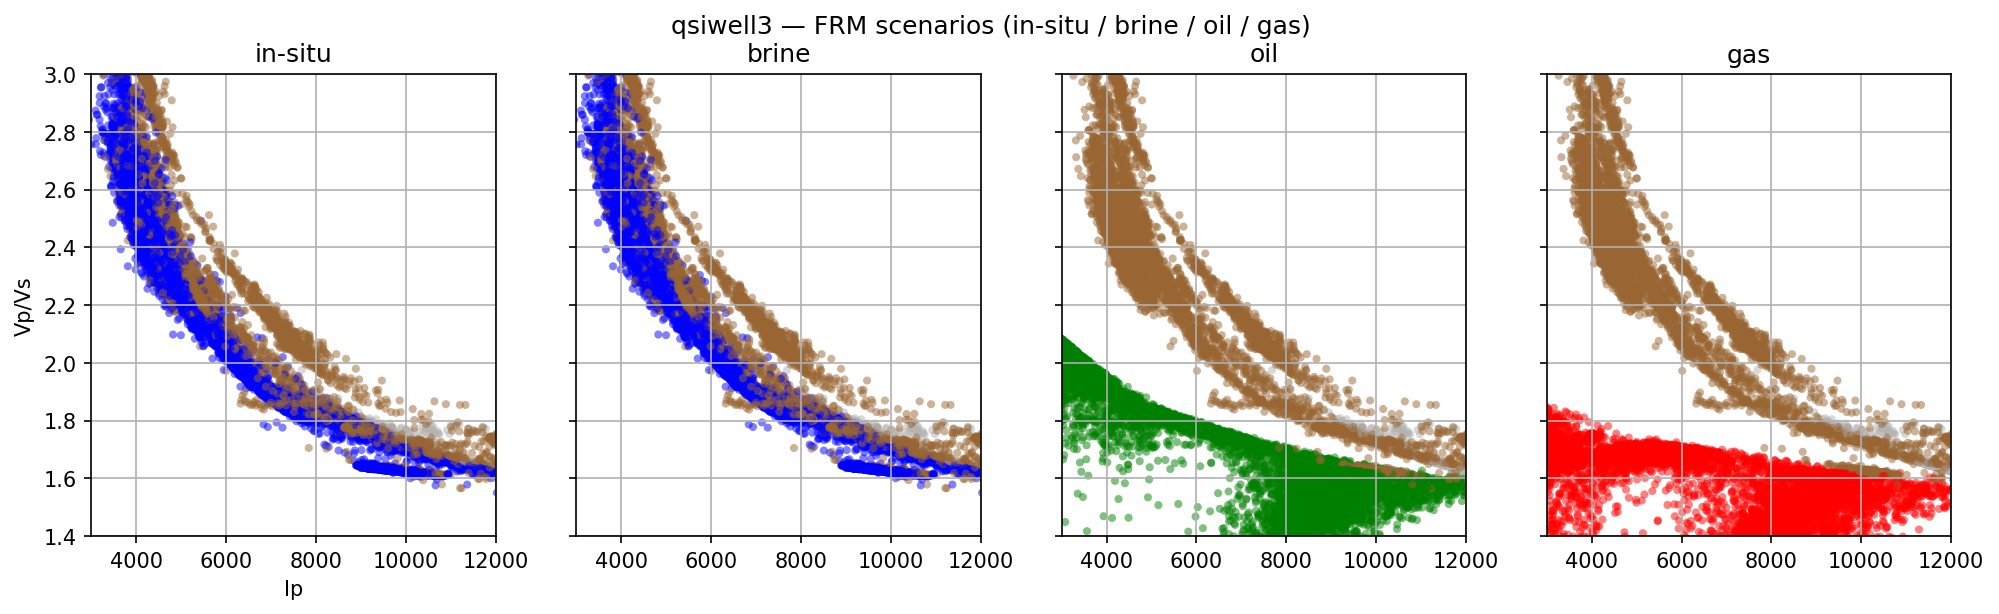

In [15]:
display(Image(filename=str(FIGURE_PATH / "qsiwell3_frm_crossplot.png")))

## 12. Keterbatasan & yang perlu didiskusikan ke Mas Irsyad

1. **Sw di qsiwell1, qsiwell3, qsiwell4, qsiwell5 itu asumsi (Sw=1), bukan data.** Nggak ada satupun dari 4 file itu yang punya log resistivity, jadi Archie nggak bisa jalan. Konsekuensinya, LFC in-situ di 4 well itu cuma bisa "brine" atau "shale", kelas "oil" cuma bisa muncul di qsiwell2. Kalau ternyata ada log resistivity yang belum di-share (RT/RESD/ILD/dll), kasih tau, tinggal drop ke folder yang sama, kode ini otomatis makenya (lihat Equation 4).
2. **Vs di qsiwell1 dan qsiwell4 itu hasil estimasi Greenberg-Castagna (1992), bukan hasil ukur.** Akurasinya udah divalidasi di Section 10 (kesalahan rata-rata sekitar 2-9% tergantung well), cukup buat forward modeling awal, tapi kalau nanti masuk ke tahap kalibrasi AVO yang lebih presisi, sebaiknya dicek ulang kalau ada data log dipole sonic asli.
3. **qsiwell3 punya ~330 sample dengan porositas mendekati nol/negatif** (kemungkinan noise pembacaan di zona tight/non-reservoir). Sample-sample ini dikeluarkan dari klasifikasi sand (jadi LFC=0/undefined) karena persamaan Gassmann secara matematis nggak stabil di porositas mendekati nol, bukan dibuang asal.
4. **Konstanta mineral dan fluida masih generic** (kuarsa-clay, brine-oil-gas standar dari textbook), belum disesuaikan per well. Kalau tiap well mewakili formasi yang beda, nilai ini idealnya diverifikasi lagi.

## Referensi

Archie, G. E. (1942). The electrical resistivity log as an aid in determining some reservoir characteristics. *Transactions of the AIME, 146*(1), 54-62.

Avseth, P., Mukerji, T., & Mavko, G. (2005). *Quantitative seismic interpretation: Applying rock physics rules to reduce interpretation risk*. Cambridge University Press.

Greenberg, M. L., & Castagna, J. P. (1992). Shear-wave velocity estimation in porous rocks, theoretical formulation, preliminary verification and applications. *Geophysical Prospecting, 40*(2), 195-209.

Makarian, E., Mirhashemi, M., Elyasi, A., Mansourian, D., Falahat, R., Radwan, A. E., El-Aal, A., Fan, C., & Li, H. (2023). A novel directional-oriented method for predicting shear wave velocity through empirical rock physics relationship using geostatistics analysis. *Scientific Reports, 13*. https://doi.org/10.1038/s41598-023-47016-9

Mavko, G., Mukerji, T., & Dvorkin, J. (2009). *The rock physics handbook* (2nd ed.). Cambridge University Press.

Amato del Monte, A. (2015). Seismic petrophysics: Part 1 and Part 2. *The Leading Edge, 34*(4 and 6).